# FRET pairs that see the motion: an elastic network on maltose-binding protein

*Which label pairs should a FRET experiment measure so that it sees a
conformational change, when only one structure is known?*

Maltose-binding protein (MBP) closes around maltose: two lobes rotate about a
hinge by about 35°. Here only the **open** structure (1OMP) is used to choose
pairs. The **closed** structure (1ANF) is loaded too, but only to check
afterwards which pairs really change distance; an experiment planned for a new
protein would not have it.

The dynamics signal is an **anisotropic elastic network** (ANM; Atilgan et al.,
Biophys J 80:505, 2001): springs between all Cα within 15 Å. Its softest normal
modes resemble functional motions such as hinge closure.
`IMP.bff.get_pair_change_probabilities` turns each pair's distance fluctuation
in the two softest modes into the probability that the distance changes by
more than 5 Å. That calibration was fitted on seven open/closed proteins, MBP
among them (`okf/esm-contacts.md`: leave-one-protein-out AUC 0.86–0.96, with
lactoferrin, a two-lobe case, the exception at 0.70).
`IMP.bff.ProbePairBenefitTerm` brings these probabilities into the
probe-network selection.

In [1]:
def example_path(relative):
    """Example data from the installed package, or from this checkout.

    ``IMP.bff.get_example_path`` reads the examples the conda module installs.
    The pip wheel deliberately does not carry them, so it raises, and the
    notebook then looks for the same file in the repository it is running from.
    """
    import pathlib
    try:
        candidate = pathlib.Path(IMP.bff.get_example_path(str(relative)))
        if candidate.exists():
            return str(candidate)
    except Exception:
        pass
    here = pathlib.Path.cwd().resolve()
    for parent in (here, *here.parents):
        candidate = parent / "examples" / relative
        if candidate.exists():
            return str(candidate)
    raise FileNotFoundError(
        f"examples/{relative} is in neither the installed package nor a parent of {here}"
    )

In [2]:
import numpy as np
import pylab as plt

import IMP
import IMP.bff

IMP.set_log_level(IMP.SILENT)          # the ligand's atoms have no CHARMM type; not needed here


def calpha(path, chain="A"):
    """Calpha coordinates of one chain by residue number, via IMP.bff's structure table."""
    t = IMP.bff.read_structure_table(path)
    xyz = np.array(t.get_xyz()).reshape(-1, 3)
    res = np.array(t.get_res_id())
    keep = [k for k, (a, c) in enumerate(zip(t.atom_name, t.chain)) if a.strip() == "CA" and c == chain]
    return {int(res[k]): xyz[k] for k in keep}


open_ca = calpha(example_path("structure/MBP/1OMP.cif"))      # apo, open: what we plan from
closed_ca = calpha(example_path("structure/MBP/1ANF.cif"))    # maltose-bound, closed: only to check
residues = sorted(set(open_ca) & set(closed_ca))
x_open = np.array([open_ca[r] for r in residues])
x_closed = np.array([closed_ca[r] for r in residues])
print(f"{len(residues)} residues in both structures ({residues[0]}..{residues[-1]})")

370 residues in both structures (1..370)


## The elastic network of the open structure

`ElasticNetworkModes` builds the network and diagonalises its Hessian. The six
rigid-body modes are dropped, so mode 0 is the softest internal motion. The
displacement of each residue in the two softest modes shows the hinge: large
on the two lobes, small near the hinge segments.

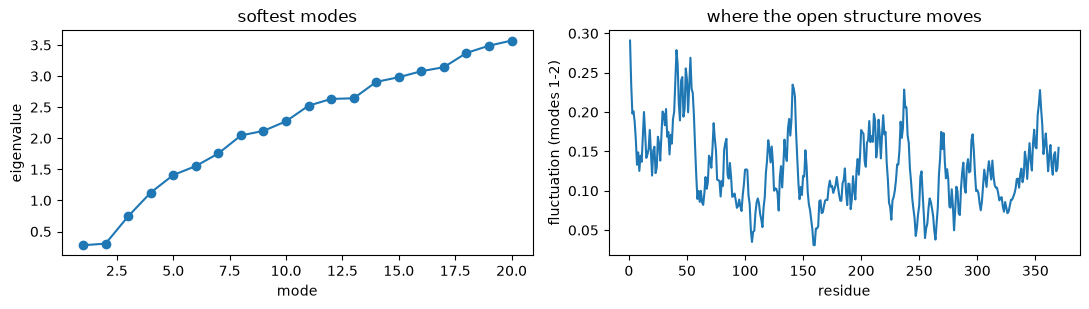

In [3]:
modes = IMP.bff.ElasticNetworkModes(x_open, 15.0)
eigenvalues = np.array(modes.get_eigenvalues())
displacement = np.zeros(len(residues))
for k in range(2):
    u = modes.get_mode(k)                                  # n x 3, unit norm over all residues
    displacement += (u ** 2).sum(1) / eigenvalues[k]       # thermal weight 1/lambda

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(np.arange(1, 21), eigenvalues[:20], "o-")
ax[0].set(xlabel="mode", ylabel="eigenvalue", title="softest modes")
ax[1].plot(residues, np.sqrt(displacement))
ax[1].set(xlabel="residue", ylabel="fluctuation (modes 1-2)", title="where the open structure moves")
plt.tight_layout(); plt.show()

## Candidate pairs and their probability of change

As stand-ins for labelling sites (in practice from the Labelizer), take every
fourth residue. A candidate pair is two such sites 25–75 Å apart in the open
structure, the range a FRET pair with R₀ ≈ 50 Å resolves. Each pair gets the
calibrated probability that its distance changes by more than 5 Å.

In [4]:
sites = np.arange(0, len(residues), 4)
pairs = np.array([(i, j) for a, i in enumerate(sites) for j in sites[a + 1:]], dtype=np.int32)
d_open = np.linalg.norm(x_open[pairs[:, 0]] - x_open[pairs[:, 1]], axis=1)
pairs, d_open = pairs[(d_open > 25) & (d_open < 75)], d_open[(d_open > 25) & (d_open < 75)]

p_change = np.array(IMP.bff.get_pair_change_probabilities(modes, pairs))
print(f"{len(sites)} sites, {len(pairs)} candidate pairs in the FRET range")
print(f"probability of a > 5 A change: median {np.median(p_change):.2f}, "
      f"{(p_change > 0.5).sum()} pairs above 0.5")

93 sites, 2483 candidate pairs in the FRET range
probability of a > 5 A change: median 0.18, 388 pairs above 0.5


## Check against the closed structure

The closed structure says what really happens. Pairs the network rates likely
to change should be the ones whose distance does change. This is a check on
the method, not part of a design.

20% of candidate pairs change by > 5 A; AUC of the predicted probability: 0.95
  p in [0.0, 0.1):   836 pairs,    1% change by > 5 A, median |change|  0.4 A
  p in [0.1, 0.3):   797 pairs,    2% change by > 5 A, median |change|  1.4 A
  p in [0.3, 0.5):   462 pairs,   32% change by > 5 A, median |change|  4.2 A
  p in [0.5, 0.7):   347 pairs,   84% change by > 5 A, median |change|  7.1 A
  p in [0.7, 1.0):    41 pairs,   85% change by > 5 A, median |change|  9.0 A


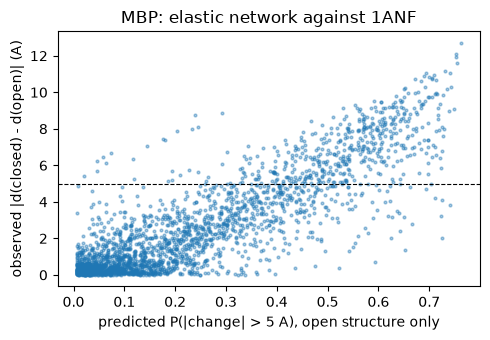

In [5]:
d_closed = np.linalg.norm(x_closed[pairs[:, 0]] - x_closed[pairs[:, 1]], axis=1)
change = np.abs(d_closed - d_open)


def auc(score, label):
    order = np.argsort(score); rank = np.empty(len(score)); rank[order] = np.arange(1, len(score) + 1)
    p, q = label.sum(), len(label) - label.sum()
    return (rank[label].sum() - p * (p + 1) / 2) / (p * q)


moving = change > 5
print(f"{moving.mean():.0%} of candidate pairs change by > 5 A; "
      f"AUC of the predicted probability: {auc(p_change, moving):.2f}")
bins = [0, 0.1, 0.3, 0.5, 0.7, 1.0]
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (p_change >= lo) & (p_change < hi)
    if m.any():
        print(f"  p in [{lo:.1f}, {hi:.1f}): {m.sum():5d} pairs, {moving[m].mean():5.0%} change by > 5 A, "
              f"median |change| {np.median(change[m]):4.1f} A")

plt.figure(figsize=(5, 3.5))
plt.scatter(p_change, change, s=4, alpha=0.4)
plt.axhline(5, color="k", lw=0.8, ls="--")
plt.xlabel("predicted P(|change| > 5 A), open structure only")
plt.ylabel("observed |d(closed) - d(open)| (A)")
plt.title("MBP: elastic network against 1ANF"); plt.tight_layout(); plt.show()

## Selecting a network that sees the motion

`ProbePairBenefitTerm` scores a set of pairs by the chance that *none* of them
sees a change, `Π(1 − d_p)`: 1 with nothing selected, falling with every
informative pair. Alone in `ProbeNetworkSelection` it picks the pairs most
likely to change. Below, six pairs chosen this way are compared with two plain
strategies that use the open structure only: six random pairs, and the six
longest distances.

chosen by the elastic network:
  residues  41-353: open 41.2 A, P(change) 0.76, observed change -12.7 A
  residues  41-209: open 27.3 A, P(change) 0.75, observed change -11.6 A
  residues  41-205: open 36.8 A, P(change) 0.75, observed change -11.9 A
  residues  41-349: open 35.8 A, P(change) 0.75, observed change -12.1 A
  residues  41-221: open 37.3 A, P(change) 0.75, observed change  -9.1 A
  residues  41-141: open 49.2 A, P(change) 0.74, observed change -10.3 A
elastic network                mean |change| 11.3 A, pairs > 5 A: 6.0 of 6
random (2000 draws)            mean |change|  2.6 A, pairs > 5 A: 1.2 of 6
longest distances              mean |change|  6.6 A, pairs > 5 A: 6.0 of 6
sites used by the elastic-network choice: [41, 141, 205, 209, 221, 349, 353]


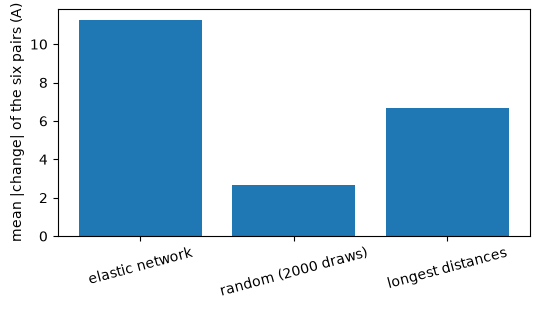

In [6]:
n_select = 6
sel = IMP.bff.ProbeNetworkSelection(len(pairs))
sel.add_term(IMP.bff.ProbePairBenefitTerm(list(p_change)), 1.0)
chosen, losses = sel.select(n_select)
chosen = np.array(chosen, dtype=int)

rng = np.random.default_rng(1)
random_sets = [rng.choice(len(pairs), n_select, replace=False) for _ in range(2000)]
longest = np.argsort(-d_open)[:n_select]

print("chosen by the elastic network:")
for k in chosen:
    i, j = pairs[k]
    print(f"  residues {residues[i]:3d}-{residues[j]:3d}: open {d_open[k]:4.1f} A, "
          f"P(change) {p_change[k]:.2f}, observed change {d_closed[k] - d_open[k]:+5.1f} A")
def report(name, mean_change, n_moving):
    print(f"{name:30s} mean |change| {mean_change:4.1f} A, pairs > 5 A: {n_moving:.1f} of {n_select}")
    return name, mean_change


summary = dict([
    report("elastic network", change[chosen].mean(), (change[chosen] > 5).sum()),
    report("random (2000 draws)", np.mean([change[s].mean() for s in random_sets]),
           np.mean([(change[s] > 5).sum() for s in random_sets])),
    report("longest distances", change[longest].mean(), (change[longest] > 5).sum()),
])
print("sites used by the elastic-network choice:", sorted(set(residues[k] for k in pairs[chosen].ravel())))

plt.figure(figsize=(5.5, 3.2))
plt.bar(list(summary), list(summary.values()))
plt.ylabel("mean |change| of the six pairs (A)")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Diversity: resolution over an ensemble from the same network

The benefit term alone stacks the single most mobile site: all six pairs above
share residue 41. A network should instead resolve the motion from several
directions. Olga's resolution term (`ProbeResolutionTerm`) does that, and the
elastic network can provide the ensemble it needs, still from the open
structure alone. The conformers below are displaced along the three softest
modes, with amplitudes in thermal proportion (1/√λ) and the largest residue
displacement about 10 Å. FRET efficiencies use R₀ = 50 Å. Resolution and
benefit are then mixed with equal weight.

In [7]:
import itertools

K, levels, R0 = 3, np.linspace(-1, 1, 5), 50.0
U = np.stack([modes.get_mode(k) / np.sqrt(eigenvalues[k]) for k in range(K)])
scale = 10.0 / np.abs(U).max() / np.sqrt(K)
frames = [x_open + scale * np.tensordot(np.array(c), U, 1) for c in itertools.product(levels, repeat=K)]
efficiency = np.array([1 / (1 + (np.linalg.norm(f[pairs[:, 0]] - f[pairs[:, 1]], axis=1) / R0) ** 6)
                       for f in frames])
rmsd = np.array([[np.sqrt(((a - c) ** 2).sum(1).mean()) for c in frames] for a in frames])
print(f"{len(frames)} conformers along modes 1-{K}, RMSD up to {rmsd.max():.1f} A")


def select(terms):
    s = IMP.bff.ProbeNetworkSelection(len(pairs))
    for term, weight in terms:
        s.add_term(term, weight)
    units, _ = s.select(n_select)
    return np.array(units, dtype=int)


def resolution():
    return IMP.bff.ProbeResolutionTerm(np.ascontiguousarray(efficiency), np.ascontiguousarray(rmsd), 0.05)


for name, terms in [("benefit", [(IMP.bff.ProbePairBenefitTerm(list(p_change)), 1.0)]),
                    ("resolution (ENM ensemble)", [(resolution(), 1.0)]),
                    ("resolution + benefit", [(resolution(), 1.0),
                                              (IMP.bff.ProbePairBenefitTerm(list(p_change)), 1.0)])]:
    c = select(terms)
    used = sorted(set(residues[k] for k in pairs[c].ravel()))
    print(f"{name:27s} mean |change| {change[c].mean():4.1f} A, > 5 A: {(change[c] > 5).sum()} of {n_select}, "
          f"{len(used)} distinct sites")

125 conformers along modes 1-3, RMSD up to 8.0 A
benefit                     mean |change| 11.3 A, > 5 A: 6 of 6, 7 distinct sites


resolution (ENM ensemble)   mean |change|  7.6 A, > 5 A: 4 of 6, 9 distinct sites
resolution + benefit        mean |change|  8.1 A, > 5 A: 5 of 6, 8 distinct sites


## With dyes: accessible volumes

A FRET experiment measures between dyes, not Cα atoms. Each candidate site
gets an accessible volume (AV1: linker 20 Å, width 4.5 Å, dye radius 3.5 Å,
attached at Cβ, the site's own side chain removed), and its mean position
stands for the dye. That changes two things:
- **which sites count:** a buried site has no AV;
- **which pairs are in range:** AV-mean distances differ from Cα distances by
  about 12 Å.

The modes stay those of the Cα network, since the dye moves with its residue.
For the projection, the direction between the two AV means and the Cα–Cα
direction give almost the same result (AUC 0.873 vs 0.883 here). So the same
`get_pair_change_probabilities` call applies, with the candidates chosen by
AV, and the check below is against the change of the AV-mean distance.

In [8]:
BACKBONE = {"N", "CA", "C", "O", "CB"}


def av_means(path, site_residues):
    """AV1 mean position of a dye at each residue (attached at CB, CA for Gly)."""
    t = IMP.bff.read_structure_table(path)
    xyz = np.array(t.get_xyz()).reshape(-1, 3)
    rad, res = np.array(t.radius), np.array(t.get_res_id())
    names = [a.strip() for a in t.atom_name]
    in_a = np.array([c == "A" for c in t.chain])
    out = {}
    for r in site_residues:
        own = (res == r) & in_a
        anchor = [k for k in np.nonzero(own)[0] if names[k] == "CB"] or                  [k for k in np.nonzero(own)[0] if names[k] == "CA"]
        if not anchor:
            continue
        keep = ~(own & np.array([n not in BACKBONE for n in names]))
        av = IMP.bff.LabelDistributionAV(list(xyz[keep].ravel()), list(rad[keep]), list(xyz[anchor[0]]),
                                         20.0, 4.5, 3.5, 0.0, 0.0, 1.0)
        if len(av.get_points()) > 0:
            out[r] = np.array(av.get_mean_position())
    return out


site_res = [residues[i] for i in sites]
av_open = av_means(example_path("structure/MBP/1OMP.cif"), site_res)
av_closed = av_means(example_path("structure/MBP/1ANF.cif"), site_res)     # only to check
labelled = [r for r in site_res if r in av_open and r in av_closed]
print(f"{len(labelled)} of {len(site_res)} candidate sites have an accessible volume")

index_of = {r: k for k, r in enumerate(residues)}
av_pairs = np.array([(index_of[a], index_of[b]) for i, a in enumerate(labelled) for b in labelled[i + 1:]],
                    dtype=np.int32)
rmp_open = np.array([np.linalg.norm(av_open[residues[i]] - av_open[residues[j]]) for i, j in av_pairs])
rmp_closed = np.array([np.linalg.norm(av_closed[residues[i]] - av_closed[residues[j]]) for i, j in av_pairs])
in_range = (rmp_open > 25) & (rmp_open < 75)
av_pairs, rmp_open, rmp_closed = av_pairs[in_range], rmp_open[in_range], rmp_closed[in_range]
p_av = np.array(IMP.bff.get_pair_change_probabilities(modes, av_pairs))
moving_av = np.abs(rmp_closed - rmp_open) > 5
print(f"{len(av_pairs)} dye pairs with AV-mean distance 25-75 A; {moving_av.mean():.0%} change by > 5 A; "
      f"AUC {auc(p_av, moving_av):.2f}")

sel = IMP.bff.ProbeNetworkSelection(len(av_pairs))
sel.add_term(IMP.bff.ProbePairBenefitTerm(list(p_av)), 1.0)
chosen_av = np.array(sel.select(n_select)[0], dtype=int)
for k in chosen_av:
    i, j = av_pairs[k]
    print(f"  {residues[i]:3d}-{residues[j]:3d}: Rmp open {rmp_open[k]:4.1f} A, P(change) {p_av[k]:.2f}, "
          f"observed {rmp_closed[k] - rmp_open[k]:+5.1f} A")
print(f"mean |change| of the chosen dye pairs {np.abs(rmp_closed - rmp_open)[chosen_av].mean():.1f} A "
      f"(all candidates {np.abs(rmp_closed - rmp_open).mean():.1f} A)")

55 of 93 candidate sites have an accessible volume
1249 dye pairs with AV-mean distance 25-75 A; 21% change by > 5 A; AUC 0.88
   41-353: Rmp open 49.9 A, P(change) 0.76, observed -16.1 A
   41-205: Rmp open 41.8 A, P(change) 0.75, observed -15.2 A
   41-221: Rmp open 41.2 A, P(change) 0.75, observed -11.4 A
   41-141: Rmp open 57.5 A, P(change) 0.74, observed -10.7 A
   41-237: Rmp open 26.1 A, P(change) 0.74, observed  +0.7 A
   41-345: Rmp open 32.4 A, P(change) 0.74, observed -11.6 A
mean |change| of the chosen dye pairs 10.9 A (all candidates 3.1 A)


## Without a crystal structure: the AlphaFold model and pLDDT

Often only a predicted structure exists. MBP's AlphaFold DB model
(AF-P0AEX9-F1, CC BY 4.0) has 396 residues: the 26-residue signal peptide
and a few tail residues are predicted with low confidence (pLDDT, stored in
the B-factor column). In an elastic network such floppy ends take over the
softest modes. Leaving the points below pLDDT 70 out of the network
(`ElasticNetworkModes(coordinates, confidence, 70)`) gives the hinge back.
The pairs are the same candidates as above, checked against 1OMP/1ANF.
AlphaFold residue = PDB residue + 26.

In [9]:
t = IMP.bff.read_structure_table(example_path("structure/MBP/AF-P0AEX9-F1.pdb"))
ca_idx = [k for k, n in enumerate(t.atom_name) if n.strip() == "CA"]
af_xyz = np.array(t.get_xyz()).reshape(-1, 3)[ca_idx]
af_plddt = np.array(t.get_bfactor())[ca_idx]
af_res = np.array(t.get_res_id())[ca_idx]
row_of = {int(r): k for k, r in enumerate(af_res)}
print(f"{len(af_res)} residues, {(af_plddt < 70).sum()} with pLDDT < 70")

af_pairs = np.array([[row_of[residues[i] + 26], row_of[residues[j] + 26]] for i, j in pairs], dtype=np.int32)
for label, net in (("all residues", IMP.bff.ElasticNetworkModes(af_xyz, 15.0)),
                   ("pLDDT >= 70", IMP.bff.ElasticNetworkModes(af_xyz, af_plddt, 70.0, 15.0))):
    p_af = np.array(IMP.bff.get_pair_change_probabilities(net, af_pairs))
    ok = ~np.isnan(p_af)
    top = moving[ok][np.argsort(-p_af[ok])[:20]].mean()
    print(f"AlphaFold model, {label:12s}: {net.get_number_of_network_points()} points, "
          f"AUC {auc(p_af[ok], moving[ok]):.2f}, top 20 changing {top:.2f}")

396 residues, 27 with pLDDT < 70


AlphaFold model, all residues: 396 points, AUC 0.70, top 20 changing 0.00
AlphaFold model, pLDDT >= 70 : 369 points, AUC 0.94, top 20 changing 0.95


## In a real design

The benefit term is one term among several. A design mixes it by weight with:
- the structural resolution (`ProbeResolutionTerm`, Olga);
- the rate information of a kinetic model (`ProbeKineticsTerm`);
- the Labelizer's site scores (`ProbeLabellingTerm`), so the sites can
  actually be labelled and a site is reused rather than a new one mutated;
- per-pair costs (`ProbePairCostTerm`, e.g. co-evolution).

```python
sel = IMP.bff.ProbeNetworkSelection(n_pairs)
sel.add_term(resolution_term)                     # over an ensemble, e.g. the ENM one above
sel.add_term(IMP.bff.ProbePairBenefitTerm(list(p_change)), 1.0)
sel.add_term(labelling_term, 0.3)
```

Limits:
- The network sees only one structure's topology. It predicts the motions
  that structure allows, not ones that need refolding.
- With two or more domains, the softest modes can move the wrong parts:
  lactoferrin is the measured failure.
- The AVs here use one generic dye. Use the actual dye's linker and radii,
  or its rotamer library, and the Labelizer's scores to choose sites.